   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   NaN   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80     NaN                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0        NaN    no   NaN   no  0.0  1.0         NaN   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  NaN  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0        NaN    no   2.0  NaN  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation                  NaN  
1  Public_Transportation                  NaN  
2  Public_Transportation        

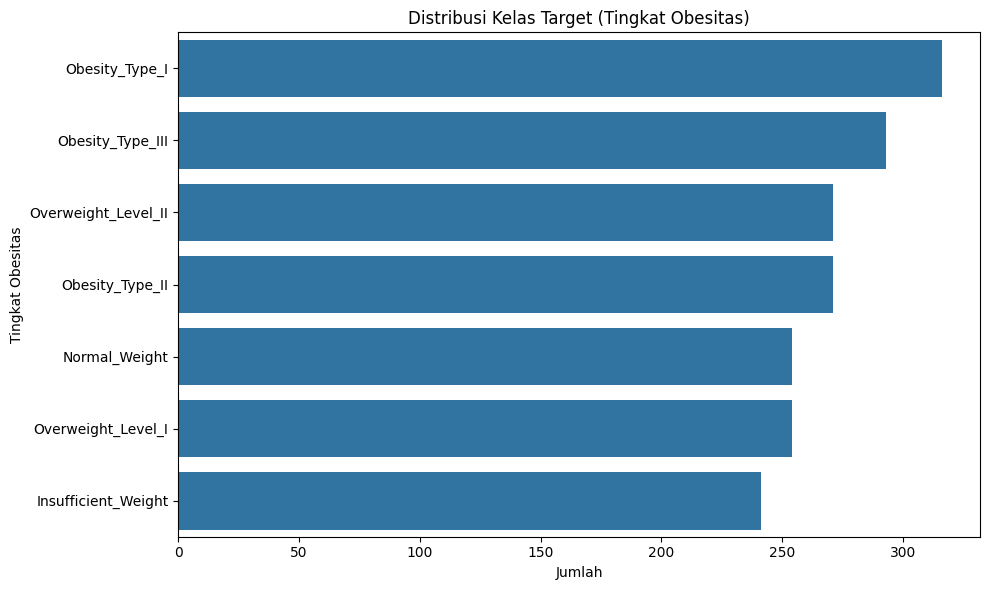

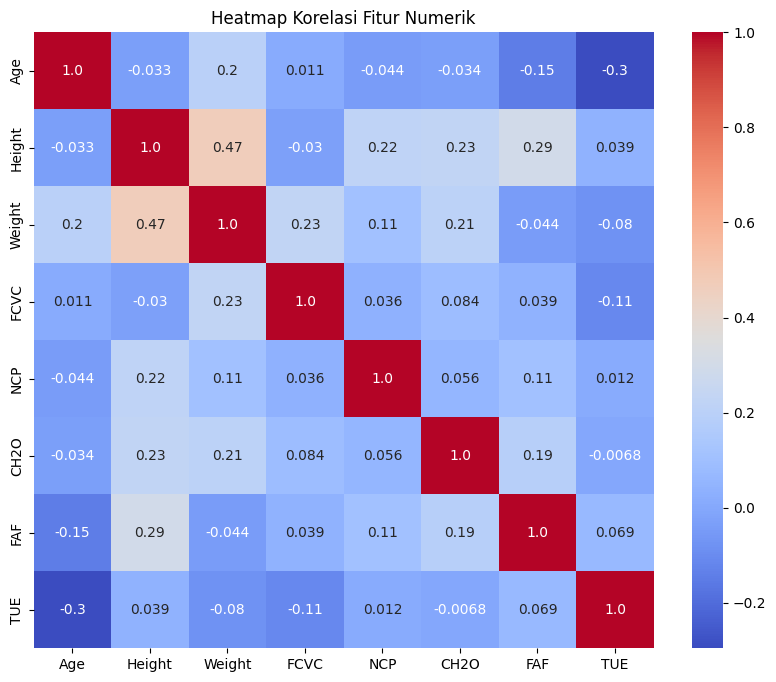

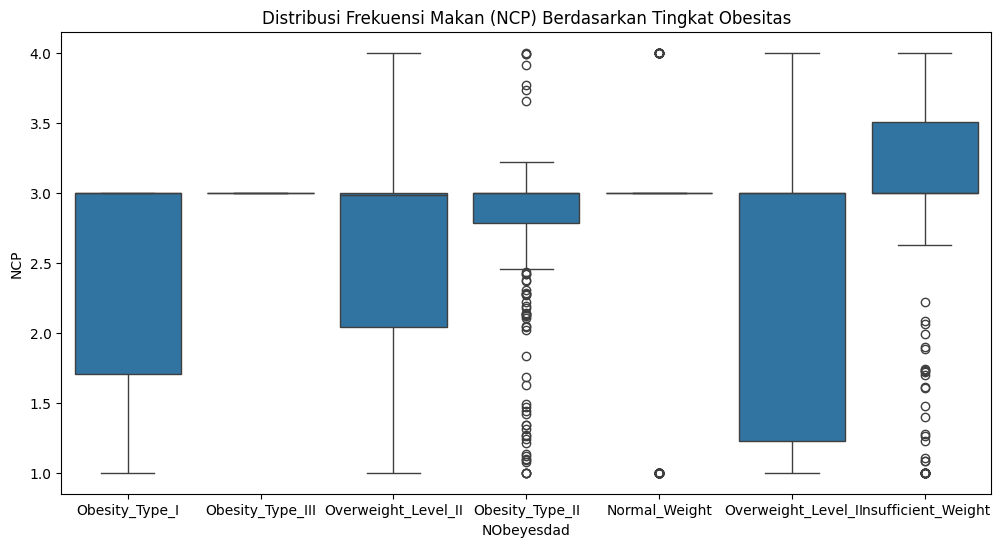

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv('estimation_of_obesity_levels_based_on_habits.csv.csv')

print(df.head())
print("jumlah data yang kosong")
print(df.isnull().sum())
print("=================================================================")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.title('Distribusi Kelas Target (Tingkat Obesitas)')
plt.xlabel('Jumlah')
plt.ylabel('Tingkat Obesitas')
plt.tight_layout()
plt.show()
print("=================================================================")
numeric_df = df.select_dtypes(include=[np.number])
korelasi = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2")
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()
print("=================================================================")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='NObeyesdad', y='NCP', order=df['NObeyesdad'].value_counts().index)
plt.title('Distribusi Frekuensi Makan (NCP) Berdasarkan Tingkat Obesitas')
plt.show()
print("=================================================================")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

df = pd.read_csv('estimation_of_obesity_levels_based_on_habits.csv.csv')

df = df.dropna(subset=['NObeyesdad'])

num_imputer = SimpleImputer(strategy='mean')
num_cols = ['Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = ['family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
print(df.isnull().sum())
df.head()


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2,Male,23.0,1.80,86.821216,yes,no,2.0,2.681134,Sometimes,no,2.000000,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.000000,no,no,3.0,3.000000,Sometimes,no,2.000000,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.800000,no,no,2.0,1.000000,Sometimes,no,2.000000,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.000000,no,yes,2.0,3.000000,Sometimes,no,2.000453,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.000000,yes,yes,3.0,3.000000,Sometimes,no,2.000000,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score


target_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}

y = df['NObeyesdad'].map(target_mapping)
X = df.drop(columns=['NObeyesdad'])

num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
ordinal_cols = ['CAEC', 'CALC']
nominal_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']

ordinal_cats = [
    ['no', 'Sometimes', 'Frequently', 'Always'],
    ['no', 'Sometimes', 'Frequently', 'Always']
]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=ordinal_cats,
                                   handle_unknown='use_encoded_value',
                                   unknown_value=-1))
    ]), ordinal_cols),
    ('nom', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore',
                                 drop='if_binary',
                                 sparse_output=False))
    ]), nominal_cols)
])

# Stratification keeps the class proportions similar between train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

models = {
    'KNN (Baseline)': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

baseline_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    baseline_pipelines[name] = pipe
    pred = pipe.predict(X_test)
    print(f'Akurasi awal {name}: {accuracy_score(y_test, pred):.4f}')

Akurasi awal KNN (Baseline): 0.7500
Akurasi awal Random Forest: 0.8947
Akurasi awal Gradient Boosting: 0.8868


,Count,Percentage
NObeyesdad,,
Obesity_Type_I,316,16.63
Obesity_Type_III,293,15.42
Overweight_Level_II,271,14.26
Obesity_Type_II,271,14.26
Normal_Weight,254,13.37
Overweight_Level_I,254,13.37
Insufficient_Weight,241,12.68


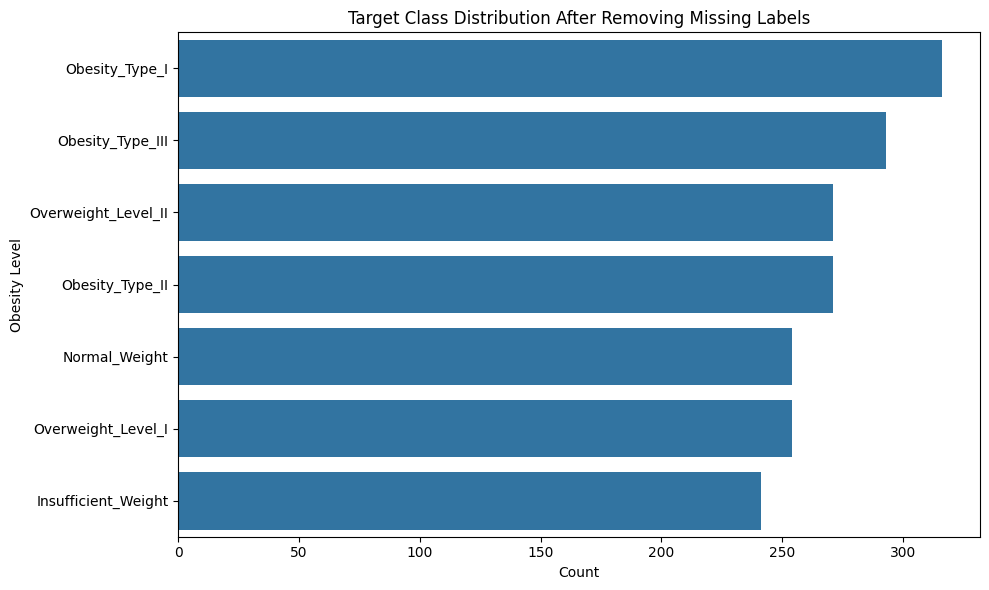

In [4]:
class_counts = df['NObeyesdad'].value_counts()
class_pct = (class_counts / class_counts.sum() * 100).round(2)
imbalance_table = pd.DataFrame({'Count': class_counts, 'Percentage': class_pct})
display(imbalance_table)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='NObeyesdad', order=class_counts.index)
plt.title('Target Class Distribution After Removing Missing Labels')
plt.xlabel('Count')
plt.ylabel('Obesity Level')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

cv_results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision_macro'].mean(),
        'CV Recall': scores['test_recall_macro'].mean(),
        'CV F1': scores['test_f1_macro'].mean()
    })

cv_table = pd.DataFrame(cv_results).sort_values('CV F1', ascending=False)
display(cv_table.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1
1,Random Forest,0.8974,0.8984,0.8945,0.8954
2,Gradient Boosting,0.8816,0.8839,0.8784,0.8797
0,KNN (Baseline),0.7638,0.7600,0.7574,0.7393


In [6]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'KNN (Baseline)': {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan']
    },
    'Random Forest': {
        'model__n_estimators': [200, 400],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3],
        'model__subsample': [0.8, 1.0]
    }
}

tuned_models = {}
tuning_summary = []

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    tuning_summary.append({
        'Model': name,
        'Best CV F1': search.best_score_,
        'Best Parameters': search.best_params_
    })
    print(f'\n{name}')
    print('Best CV F1:', round(search.best_score_, 4))
    print('Best parameters:', search.best_params_)

tuning_table = pd.DataFrame(tuning_summary)
display(tuning_table)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

KNN (Baseline)
Best CV F1: 0.8269
Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Random Forest
Best CV F1: 0.8998
Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Gradient Boosting
Best CV F1: 0.896
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


,Model,Best CV F1,Best Parameters
0,KNN (Baseline),0.826909,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,Random Forest,0.899816,"{'model__max_depth': 20, 'model__min_samples_l..."
2,Gradient Boosting,0.895988,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

label_names = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

evaluation_rows = []
predictions = {}

for name, pipe in tuned_models.items():
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    evaluation_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-score (Macro)': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })

evaluation_table = pd.DataFrame(evaluation_rows).sort_values('F1-score (Macro)', ascending=False)
display(evaluation_table.round(4))

best_model_name = evaluation_table.iloc[0]['Model']
best_pipeline = tuned_models[best_model_name]
print('Best model based on Macro F1:', best_model_name)
print('\nClassification report:')
print(classification_report(y_test, predictions[best_model_name], target_names=label_names, zero_division=0))

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro)
1,Random Forest,0.9053,0.9076,0.9043,0.9041
2,Gradient Boosting,0.9026,0.9016,0.9037,0.9019
0,KNN (Baseline),0.8447,0.8451,0.8392,0.8347


Best model based on Macro F1: Random Forest

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.96      0.96        48
      Normal_Weight       0.71      0.86      0.78        51
 Overweight_Level_I       0.88      0.82      0.85        51
Overweight_Level_II       0.90      0.81      0.85        54
     Obesity_Type_I       0.98      0.89      0.93        63
    Obesity_Type_II       0.95      0.98      0.96        54
   Obesity_Type_III       0.98      1.00      0.99        59

           accuracy                           0.91       380
          macro avg       0.91      0.90      0.90       380
       weighted avg       0.91      0.91      0.91       380



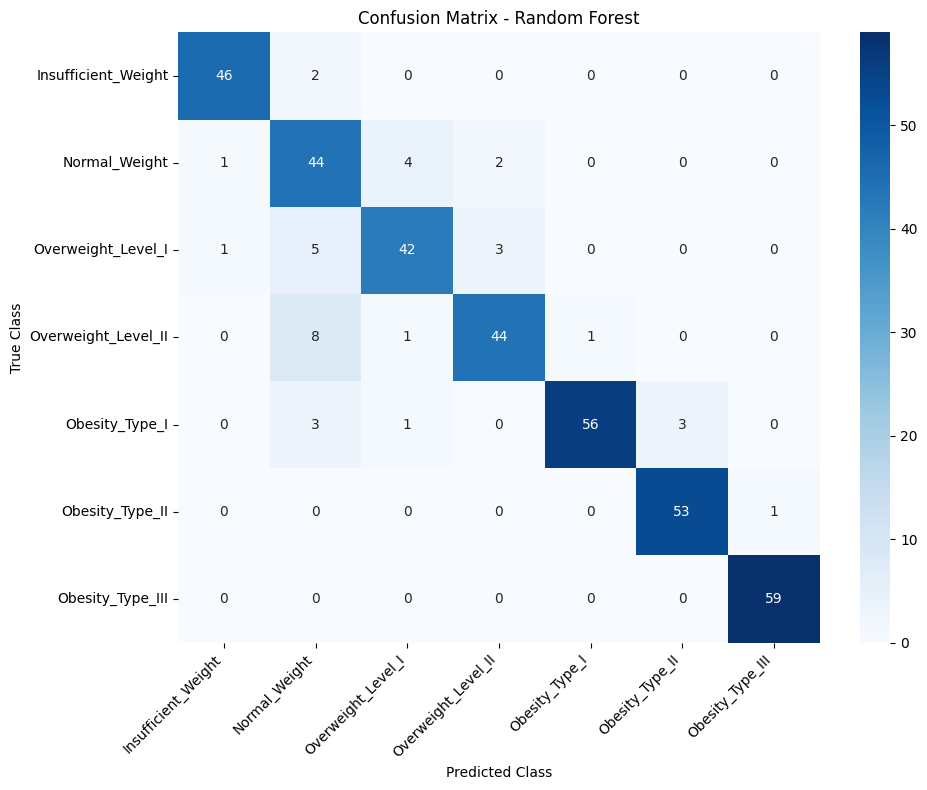

Largest off-diagonal error count: 8
True: Overweight_Level_II -> Predicted: Normal_Weight


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Most frequent incorrect class pairs
cm_error = cm.copy()
np.fill_diagonal(cm_error, 0)
error_positions = np.argwhere(cm_error == cm_error.max())
print('Largest off-diagonal error count:', cm_error.max())
for i, j in error_positions:
    print(f'True: {label_names[i]} -> Predicted: {label_names[j]}')

In [9]:
import joblib

joblib.dump(best_pipeline, 'best_obesity_pipeline.joblib')
print(f'Saved: best_obesity_pipeline.joblib ({best_model_name})')

Saved: best_obesity_pipeline.joblib (Random Forest)


In [ ]:
import joblib
import streamlit as st
import pandas as pd
from pathlib import Path

app_code = '''
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Obesity Level Classifier",
    page_icon="🏥",
    layout="centered"
)

MODEL_PATH = "best_obesity_pipeline.joblib"

try:
    model = joblib.load(MODEL_PATH)
except FileNotFoundError:
    st.error(
        "Model file 'best_obesity_pipeline.joblib' was not found. "
        "Please place the model file in the same folder as app.py."
    )
    st.stop()

LABELS = {
    0: "Insufficient_Weight",
    1: "Normal_Weight",
    2: "Overweight_Level_I",
    3: "Overweight_Level_II",
    4: "Obesity_Type_I",
    5: "Obesity_Type_II",
    6: "Obesity_Type_III"
}

st.title("🏥 Obesity Level Classifier")

st.write(
    """
    This application predicts an individual's obesity level
    using anthropometric measurements and lifestyle-related
    factors through a trained machine learning pipeline.
    """
)

st.info(
    """
    **Academic Project Disclaimer**

    This application is developed for machine-learning project
    demonstration purposes. The prediction is not a medical
    diagnosis and should not replace professional medical advice.
    """
)

with st.form("obesity_prediction_form"):

    st.header("👤 Personal Information")

    gender = st.selectbox("Gender", ["Female", "Male"])
    age = st.number_input("Age", min_value=1.0, max_value=100.0, value=21.0, step=1.0)
    height = st.number_input("Height (meters)", min_value=1.0, max_value=2.5, value=1.65, step=0.01)
    weight = st.number_input("Weight (kg)", min_value=20.0, max_value=250.0, value=60.0, step=0.5)

    st.header("🍽️ Eating Habits")
    family_history = st.selectbox("Family history with overweight", ["yes", "no"])
    favc = st.selectbox("Frequent consumption of high-caloric food (FAVC)", ["yes", "no"])
    fcvc = st.number_input("Frequency of vegetable consumption (FCVC)", min_value=0.0, max_value=3.0, value=2.0, step=0.1)
    ncp = st.number_input("Number of main meals per day (NCP)", min_value=0.0, max_value=6.0, value=3.0, step=0.1)
    caec = st.selectbox("Consumption of food between meals (CAEC)", ["no", "Sometimes", "Frequently", "Always"])
    calc = st.selectbox("Alcohol consumption (CALC)", ["no", "Sometimes", "Frequently", "Always"])

    st.header("🏃 Lifestyle")
    smoke = st.selectbox("Smoking (SMOKE)", ["yes", "no"])
    ch2o = st.number_input("Daily water consumption (CH2O)", min_value=0.0, max_value=5.0, value=2.0, step=0.1)
    scc = st.selectbox("Calories consumption monitoring (SCC)", ["yes", "no"])
    faf = st.number_input("Physical activity frequency (FAF)", min_value=0.0, max_value=5.0, value=1.0, step=0.1)
    tue = st.number_input("Time using technology devices (TUE)", min_value=0.0, max_value=5.0, value=1.0, step=0.1)
    mtrans = st.selectbox("Main transportation mode (MTRANS)", ["Automobile", "Bike", "Motorbike", "Public_Transportation", "Walking"])

    submitted = st.form_submit_button("🔮 Predict Obesity Level")

if submitted:
    input_data = pd.DataFrame([{
        "Gender": gender, "Age": age, "Height": height, "Weight": weight,
        "family_history_with_overweight": family_history, "FAVC": favc,
        "FCVC": fcvc, "NCP": ncp, "CAEC": caec, "SMOKE": smoke,
        "CH2O": ch2o, "SCC": scc, "FAF": faf, "TUE": tue,
        "CALC": calc, "MTRANS": mtrans
    }])

    try:
        prediction = model.predict(input_data)[0]
        prediction = int(prediction)

        predicted_label = LABELS.get(prediction, "Unknown Class")

        st.divider()
        st.header("📊 Prediction Result")
        st.success(f"### Predicted Obesity Level: {predicted_label}")

        bmi = weight / (height ** 2)
        st.metric(label="BMI", value=f"{bmi:.2f}")

        st.caption("BMI is shown as additional information. It is not added as a separate model feature.")

        with st.expander("🔎 View Input Data"):
            st.dataframe(input_data, use_container_width=True)

    except Exception as error:
        st.error("An error occurred while making the prediction.")
        st.exception(error)

st.divider()
st.caption("Machine Learning Final Project — Obesity Level Classification")
'''

# 1. Generate app.py
with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code.strip())

print(f"✓ Complete Streamlit app generated: {Path('app.py').resolve()}")

# 2. Generate requirements.txt
requirements = """pandas
numpy
scikit-learn
joblib
streamlit
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print(f"✓ requirements.txt generated: {Path('requirements.txt').resolve()}")

# 3. Generate README.md
readme = """# Obesity Level Classification

Machine Learning project for obesity level classification.

## Run
streamlit run app.py
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print(f"✓ README.md generated: {Path('README.md').resolve()}")
print("Deployment files generated successfully!")

✓ Complete Streamlit app generated: /content/app.py
Deployment files generated successfully!


In [13]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 40.5 MB/s eta 0:00:00
